# 01 - QC Exploration (Week 2): Compute & Visualize QC Metrics — NO FILTERING

**Goal:** Compute and visualize QC metrics from the raw `filtered_feature_bc_matrix.h5` file WITHOUT applying any filtering, normalization, or clustering. Save all outputs to `results/qc/`.

**Dataset identity:** 3k PBMCs from a healthy donor
**DOI:** https://doi.org/10.6084/m9.figshare.28414916

**Scope guard:** This notebook performs only data inspection and QC metric computation for Week 2. Do NOT change thresholds, do NOT apply filtering/normalization/clustering in this notebook. Any decision to filter or change parameters must be deferred to the main pipeline and documented in `protocol/decision_log.md`.

**Outputs (root):** results/qc/tables/ and results/qc/figures/

## Note: Exploration Only
This notebook computes QC metrics but applies NO filtering.
Filtering will be performed in a separate notebook following preregistered thresholds.

## 1) Environment Verification

**Goal:** Confirm environment reproducibility by printing versions of key packages and recording a seed to use for any stochastic steps outside this notebook.

**Inputs:** `ENVIRONMENT.md` (list of required packages).

**Actions (manual):** Print versions for Python, numpy, scipy, pandas, scanpy/anndata, matplotlib/seaborn, and save output to `results/qc/tables/env_versions.txt`.

**Outputs:** `results/qc/tables/env_versions.txt`

**Pass/Fail check:** Versions printed and saved.

In [15]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import sys
from importlib.metadata import version

import numpy as np
import scipy as sp
import pandas as pd
import scanpy as sc
import anndata as an
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import random
import yaml
import os

print(f"Python Version: {sys.version}")
print(f"Python Executable: {sys.executable}")
print(f"NumPy Version: {np.__version__}")
print(f"SciPy Version: {sp.__version__}")
print(f"Pandas Version: {pd.__version__}")
print(f"Scanpy Version: {sc.__version__}")
print(f"AnnData Version: {version('anndata')}")
print(f"Matplotlib Version: {matplotlib.__version__}")
print(f"Seaborn Version: {sns.__version__}")

Python Version: 3.11.14 (main, Oct 10 2025, 08:54:03) [GCC 11.4.0]
Python Executable: /home/godfather/2026_bio_projects/pbmc_scRNA_clustering_markers/.venv/bin/python
NumPy Version: 1.26.4
SciPy Version: 1.16.3
Pandas Version: 2.2.2
Scanpy Version: 1.10.2
AnnData Version: 0.12.10
Matplotlib Version: 3.8.4
Seaborn Version: 0.13.2


## 2) Load Config

**Goal:** Load and record the QC- and pipeline-related configuration values that will guide interpretation (no changes).

**Inputs:** `config/qc.yaml` and `config/pipeline.yaml`

**Fields to read and record:**
- From `config/qc.yaml`: `min_genes`, `max_genes`, `max_mito_pct`, `min_cells_per_gene`
- From `config/pipeline.yaml`: any noted preprocessing instructions or `seed` (if present).

**Actions (manual):** Load the YAMLs, echo key values into notebook output, and save a snapshot file `results/qc/tables/config_snapshot.json` (or .txt).

**Outputs:** `results/qc/tables/config_snapshot.json`

**Pass/Fail check:** Snapshot saved and matches source YAML values.

In [ ]:
# TODO: Load `config/qc.yaml` and `config/pipeline.yaml`.
# TODO: Extract: min_genes, max_genes, max_mito_pct, min_cells_per_gene.
# TODO: Extract any `seed` or preprocessing notes from pipeline.yaml; if absent, record as 'null' and document.
# TODO: Print extracted values and write them to `results/qc/tables/config_snapshot.json`.


with open('../config/pipeline.yaml', 'r') as pipeline:
    pipeline = yaml.safe_load(pipeline)

with open('../config/qc.yaml', 'r') as qc:
    qc = yaml.safe_load(qc)


seed = pipeline['random_seed']
np.random.seed(seed)
random.seed(seed)
sc.settings.seed = seed

qc_params = {
    'min_genes': qc['min_genes'],
    'max_genes': qc['max_genes'],
    'max_mito_pct': qc['max_mito_pct'],
    'min_cells_per_gene': qc['min_cells_per_gene']
}
print(f"Seed: {seed}")
print(f"QC Thresholds: {qc_params}")

Seed: 42
Minimum Genes: 300
Maximum Genes: 2500
Max Mitochondrial Percentage: 10%
Minimum cells per gene: 3


## 3) Load Dataset

**Goal:** Load the raw 10x HDF5 feature-barcode matrix and confirm basic shape and integrity (no filtering).

**Inputs:** `data/raw/filtered_feature_bc_matrix.h5` (expected: 2,752 cells; 54,950 features as documented in `DATA_SOURCE.md`).

**Actions (manual):** Load the H5, print the observed matrix shape, confirm count values are integers, and check that gene symbol/name fields are present. Document any discrepancies.

**Outputs:** `results/qc/tables/dataset_shape.txt`

**Pass/Fail check:** Observed shape matches expectation or discrepancy documented.

In [26]:
# TODO: Open `data/raw/filtered_feature_bc_matrix.h5` (10x HDF5).
# TODO: Read the count matrix shape and write the shape to `results/qc/tables/dataset_shape.txt`.
# TODO: Check that UMI counts are integers (or castable) and report any non-integer values.
# TODO: Verify presence of gene IDs/symbols and document which annotation field is being used (e.g., gene_symbols or feature_name).
import warnings
warnings.filterwarnings(
    "ignore",
    message="Variable names are not unique.*"
)


adata = sc.read_10x_h5("../data/raw/filtered_feature_bc_matrix.h5")
adata.var_names_make_unique()

print(f"{adata}")
print(f"Data type of matrix values: {np.dtype(adata.X)}")
print(f"{adata.obs}")
print(f"{adata.var}")

AnnData object with n_obs × n_vars = 2752 × 54950
    var: 'gene_ids', 'feature_types', 'genome'
Data type of matrix values: float32
Empty DataFrame
Columns: []
Index: [AAACATACAACCAC-1, AAACATTGAGCTAC-1, AAACATTGATCAGC-1, AAACCGTGCTTCCG-1, AAACCGTGTATGCG-1, AAACGCACTGGTAC-1, AAACGCTGACCAGT-1, AAACGCTGGTTCTT-1, AAACGCTGTAGCCA-1, AAACGCTGTTTCTG-1, AAACTTGAAAAACG-1, AAACTTGATCCAGA-1, AAAGAGACGAGATA-1, AAAGAGACGCGAGA-1, AAAGAGACGGACTT-1, AAAGAGACGGCATT-1, AAAGATCTGGGCAA-1, AAAGCAGAAGCCAT-1, AAAGCAGATATCGG-1, AAAGCCTGTATGCG-1, AAAGGCCTGTCTAG-1, AAAGTTTGATCACG-1, AAAGTTTGGGGTGA-1, AAAGTTTGTAGAGA-1, AAAGTTTGTAGCGT-1, AAATCAACAATGCC-1, AAATCAACACCAGT-1, AAATCAACCAGGAG-1, AAATCAACCCTATT-1, AAATCAACGGAAGC-1, AAATCAACTCGCAA-1, AAATCATGACCACA-1, AAATCCCTCCACAA-1, AAATCCCTGCTATG-1, AAATGGGAAGGCGA-1, AAATGTTGAACGAA-1, AAATGTTGCCACAA-1, AAATGTTGTGGCAT-1, AAATTCGAAGGTTC-1, AAATTCGAATCACG-1, AAATTCGAGCTGAT-1, AAATTCGAGGAGTG-1, AAATTCGATTCTCA-1, AAATTGACACGACT-1, AAATTGACTCGCTC-1, AACAAACTCATTTC-1, AAC

## 4) Compute QC Metrics

**Goal:** Compute per-cell QC metrics and attach them to the AnnData/adata.obs structure (do not filter).

**Metrics required:** total counts per cell, n_genes per cell, percent mitochondrial. Optional: percent ribosomal.

**Meaning / artifacts:**
- Total counts per cell: low values indicate low-quality or empty droplets; high values may indicate doublets.\n
- n_genes per cell: low gene counts indicate poor capture; very high counts can indicate doublets or ambient contamination.\n
- percent mitochondrial: high percentages often indicate damaged or dying cells.\n

**Actions (manual):** Compute metrics, store in `adata.obs`, and save a small head sample `results/qc/tables/qc_metrics_head.csv`.

**Outputs:** `results/qc/tables/qc_metrics_head.csv`

**Pass/Fail check:** Metrics exist in `adata.obs` and are non-null.

In [ ]:
# TODO: Compute the following and add to adata.obs (or equivalent):
# TODO: - 'total_counts' (sum of counts per cell)
# TODO: - 'n_genes_by_counts' (number of genes with >0 counts per cell)
# TODO: - 'pct_counts_mt' (fraction of counts mapping to mitochondrial genes * 100)
# TODO: - (optional) 'pct_counts_ribo' for ribosomal genes
# TODO: Save the first ~20 rows of the resulting obs table to `results/qc/tables/qc_metrics_head.csv`.

adata.var['mt'] = adata.var.index.str.upper().str.startswith("MT-")
adata.var['ribo'] = (adata.var.index.str.upper().str.startswith('RPS') |
                     adata.var.index.str.upper().str.startswith('RPL'))

sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'ribo'], inplace=True)

print(adata.obs['total_counts'].head(20))
print(f"Mitochondrial genes identified: {adata.var['mt'].sum()}")
print(f"Ribosomal genes identified: {adata.var['ribo'].sum()}")

AAACATACAACCAC-1    2842.0
AAACATTGAGCTAC-1    5714.0
AAACATTGATCAGC-1    3762.0
AAACCGTGCTTCCG-1    2977.0
AAACCGTGTATGCG-1    1228.0
AAACGCACTGGTAC-1    2533.0
AAACGCTGACCAGT-1    2636.0
AAACGCTGGTTCTT-1    2621.0
AAACGCTGTAGCCA-1    1635.0
AAACGCTGTTTCTG-1    1264.0
AAACTTGAAAAACG-1    4570.0
AAACTTGATCCAGA-1    2894.0
AAAGAGACGAGATA-1    2724.0
AAAGAGACGCGAGA-1    3431.0
AAAGAGACGGACTT-1    1429.0
AAAGAGACGGCATT-1     953.0
AAAGATCTGGGCAA-1    1553.0
AAAGCAGAAGCCAT-1    1356.0
AAAGCAGATATCGG-1    5073.0
AAAGCCTGTATGCG-1    3414.0
Name: total_counts, dtype: float32


## 5) QC Summary Table

**Goal:** Produce summary statistics (mean, median, std, min, max) for each QC metric to aid rapid assessment.

**Summary stats to compute:** mean / median / std / min / max for total_counts, n_genes_by_counts, pct_counts_mt (and pct_counts_ribo if computed).

**Actions (manual):** Compute the summary table and save to `results/qc/tables/qc_summary.csv`.

**Outputs:** `results/qc/tables/qc_summary.csv`

**Pass/Fail check:** Table saved and values plausible.

In [28]:
# TODO: Compute summary statistics (mean, median, std, min, max) for each QC metric.
# TODO: Save the summary to `results/qc/tables/qc_summary.csv`.
# TODO: Include column names and units where appropriate (e.g., pct_counts_mt is a percent).
adata.obs[["total_counts", "n_genes_by_counts", "total_counts_mt", 'total_counts_ribo']].describe()

,total_counts,n_genes_by_counts,total_counts_mt,total_counts_ribo
count,2752.000000,2752.000000,2752.000000,2752.000000
mean,2700.420410,1075.821584,49.879723,826.360474
std,1250.490845,350.074015,31.480165,427.022583
min,500.000000,206.000000,0.000000,4.000000
25%,2043.000000,893.750000,30.000000,528.750000
50%,2535.500000,1049.000000,43.000000,787.000000
75%,3168.250000,1215.250000,61.000000,1074.250000
max,18856.000000,3808.000000,339.000000,4386.000000


## 6) QC Plots

**Goal:** Create diagnostic plots to visualize QC distributions and relationships. Save each figure to `results/qc/figures/` with the specified filenames so they are reproducible artifacts.

**Plots required:**
- Histogram: total counts  -> `hist_total_counts.png`\n
- Histogram: genes per cell -> `hist_n_genes.png`\n
- Histogram: mito % -> `hist_pct_mito.png`\n
- Scatter: total counts vs n_genes -> `scatter_counts_vs_genes.png`\n
- Optional: violin plots for the three metrics -> `violin_qc_metrics.png`

**What to look for:** low-quality tails (low counts / low genes), heavy upper tails (possible doublets), mito-heavy tail (high pct_mt).

**Pass/Fail check:** All figures saved to `results/qc/figures/` with correct filenames.

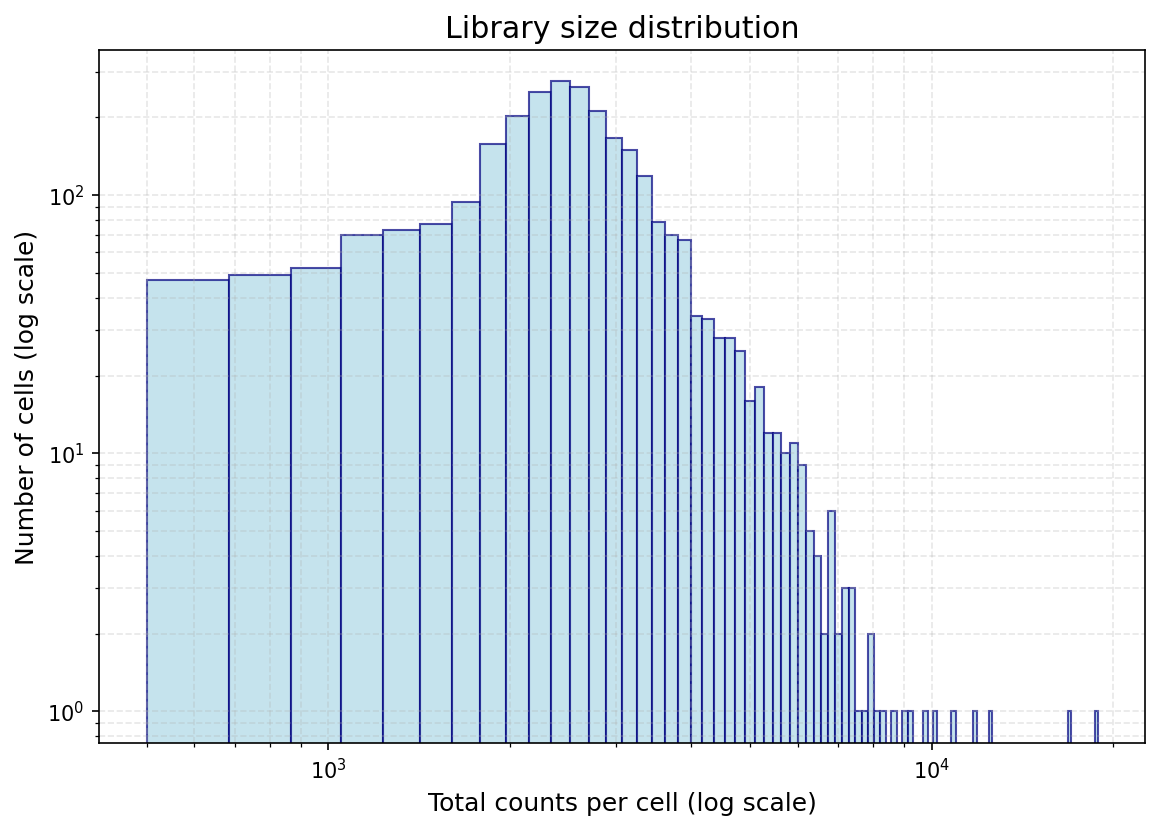

In [39]:
# TODO: Generate histogram of total counts per cell and save as results/qc/figures/hist_total_counts.png.
# TODO: Use log-scaled x-axis if counts are highly skewed; annotate median and 10th/90th percentiles.
# TODO: Save the figure to disk (not only display).

plt.figure(figsize=(9, 6))
plt.hist(adata.obs['total_counts'], bins=100, color='lightblue', edgecolor='navy', alpha=0.7)
plt.yscale('log')
plt.xscale('log')               # ← add log x-axis for skewed data
plt.xlabel('Total counts per cell (log scale)')
plt.ylabel('Number of cells (log scale)')
plt.title('Library size distribution')
plt.grid(True, which='both', alpha=0.3, linestyle='--')
plt.minorticks_on()
plt.savefig('../results/qc/total_counts_per_cell.png')
plt.show()

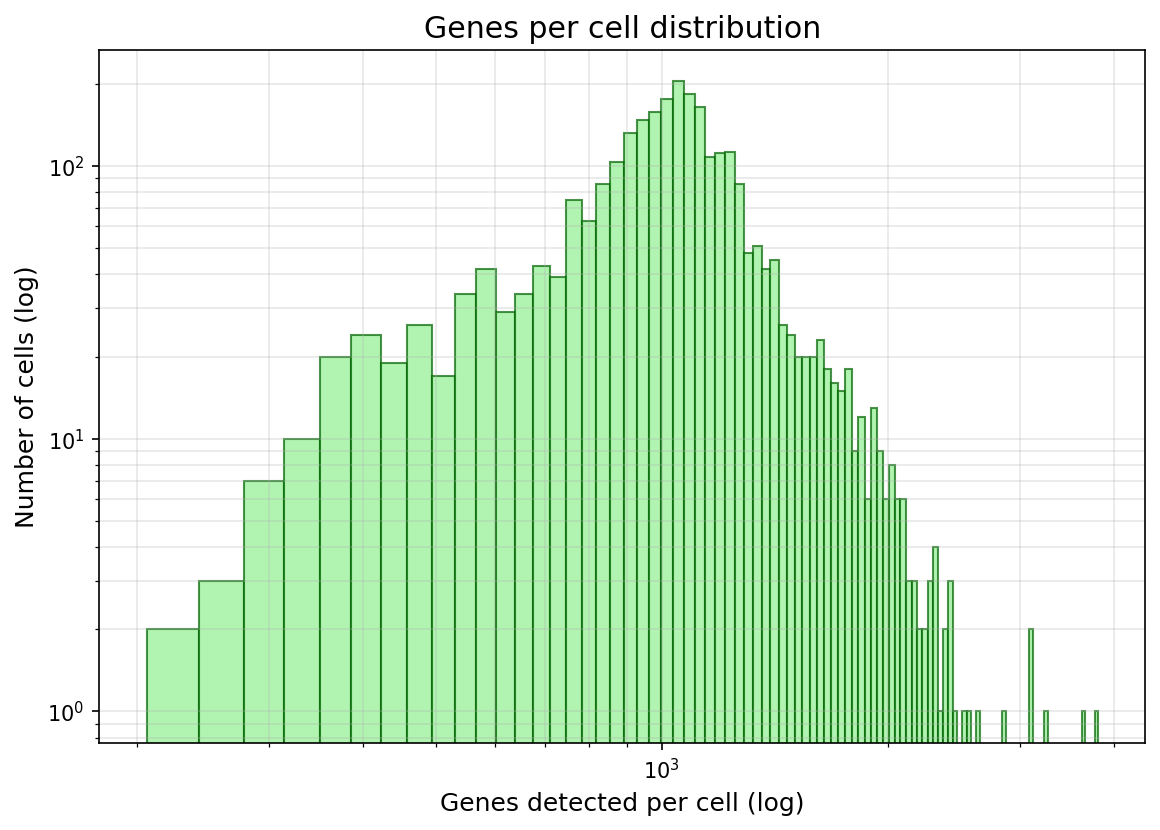

In [38]:
# TODO: Generate histogram of genes per cell and save as results/qc/figures/hist_n_genes.png.
# TODO: Annotate median and 10th/90th percentiles.
# TODO: Save the figure to disk.
plt.figure(figsize=(9, 6))
plt.hist(adata.obs['n_genes_by_counts'], bins=100, color='lightgreen', edgecolor='darkgreen', alpha=0.7)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Genes detected per cell (log)')
plt.ylabel('Number of cells (log)')
plt.title('Genes per cell distribution')
plt.grid(True, which='both', alpha=0.3)
plt.savefig('../results/qc/genes_per_cell.png')
plt.show()

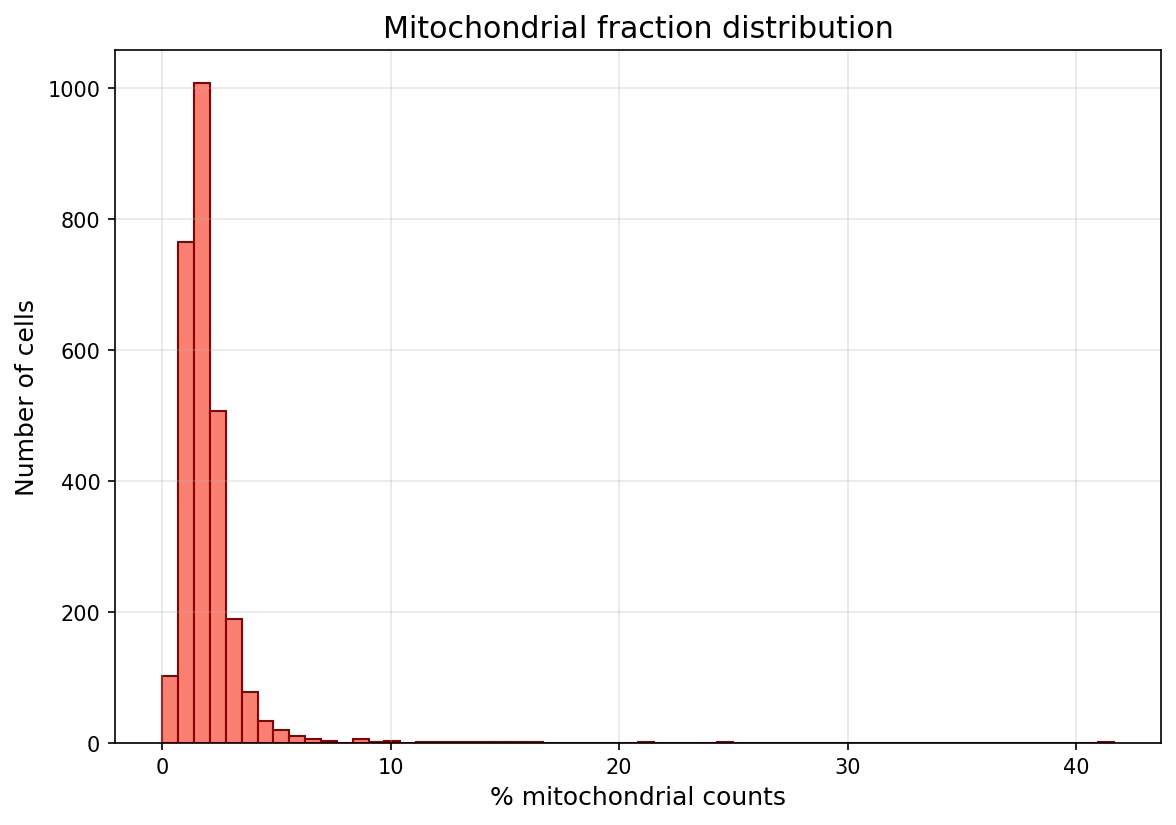

In [37]:
# TODO: Generate histogram of percent mitochondrial and save as results/qc/figures/hist_pct_mito.png.
# TODO: Mark the configured threshold from config/qc.yaml (e.g., 10%) on the plot but DO NOT apply it.
# TODO: Save the figure to disk.
plt.figure(figsize=(9, 6))
plt.hist(adata.obs['pct_counts_mt'], bins=60, color='salmon', edgecolor='darkred')
plt.xlabel('% mitochondrial counts')
plt.ylabel('Number of cells')
plt.title('Mitochondrial fraction distribution')
plt.grid(True, alpha=0.3)
plt.savefig('../results/qc/mito_distr.png')
plt.show()

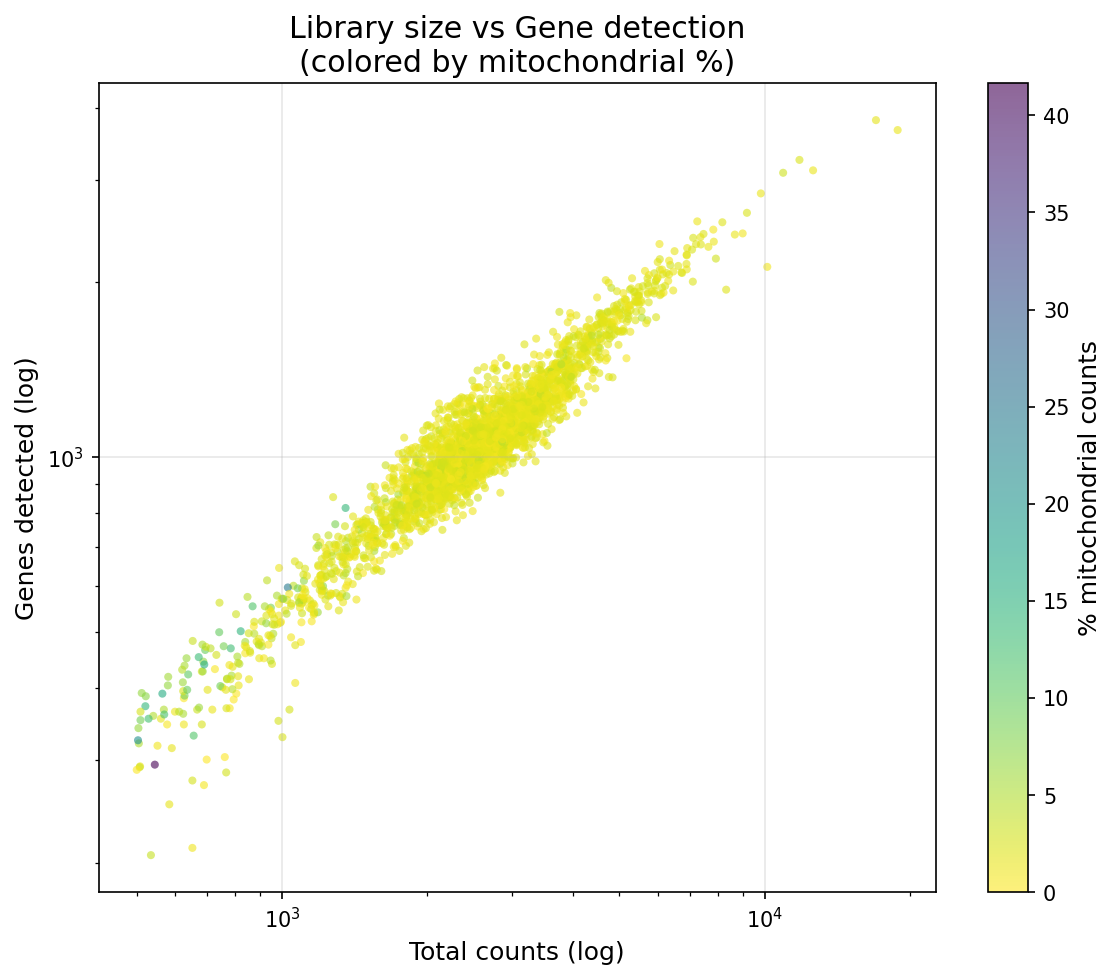

In [36]:
# TODO: Generate scatter plot of total counts vs n_genes and save as results/qc/figures/scatter_counts_vs_genes.png.
# TODO: Optionally color points by pct_counts_mt to visualize mito-driven clusters.
# TODO: Save the figure to disk.
plt.figure(figsize=(9, 7))
sc = plt.scatter(
    adata.obs['total_counts'],
    adata.obs['n_genes_by_counts'],
    c=adata.obs['pct_counts_mt'],
    cmap='viridis_r',           # reversed viridis → high mito = yellow/red
    alpha=0.6,
    s=15,                       # smaller points if many cells
    edgecolor='none'
)
plt.colorbar(sc, label='% mitochondrial counts')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Total counts (log)')
plt.ylabel('Genes detected (log)')
plt.title('Library size vs Gene detection\n(colored by mitochondrial %)')
plt.grid(True, alpha=0.3)
plt.savefig('../results/qc/tc_vs_ngenes_scatter.png')
plt.show()


In [33]:
import scanpy as sc
import matplotlib.pyplot as plt
print(type(sc.pl))                  # MUST print something like <module 'scanpy.plotting._anndata'>
print('violin' in dir(sc.pl))

<class 'module'>
True


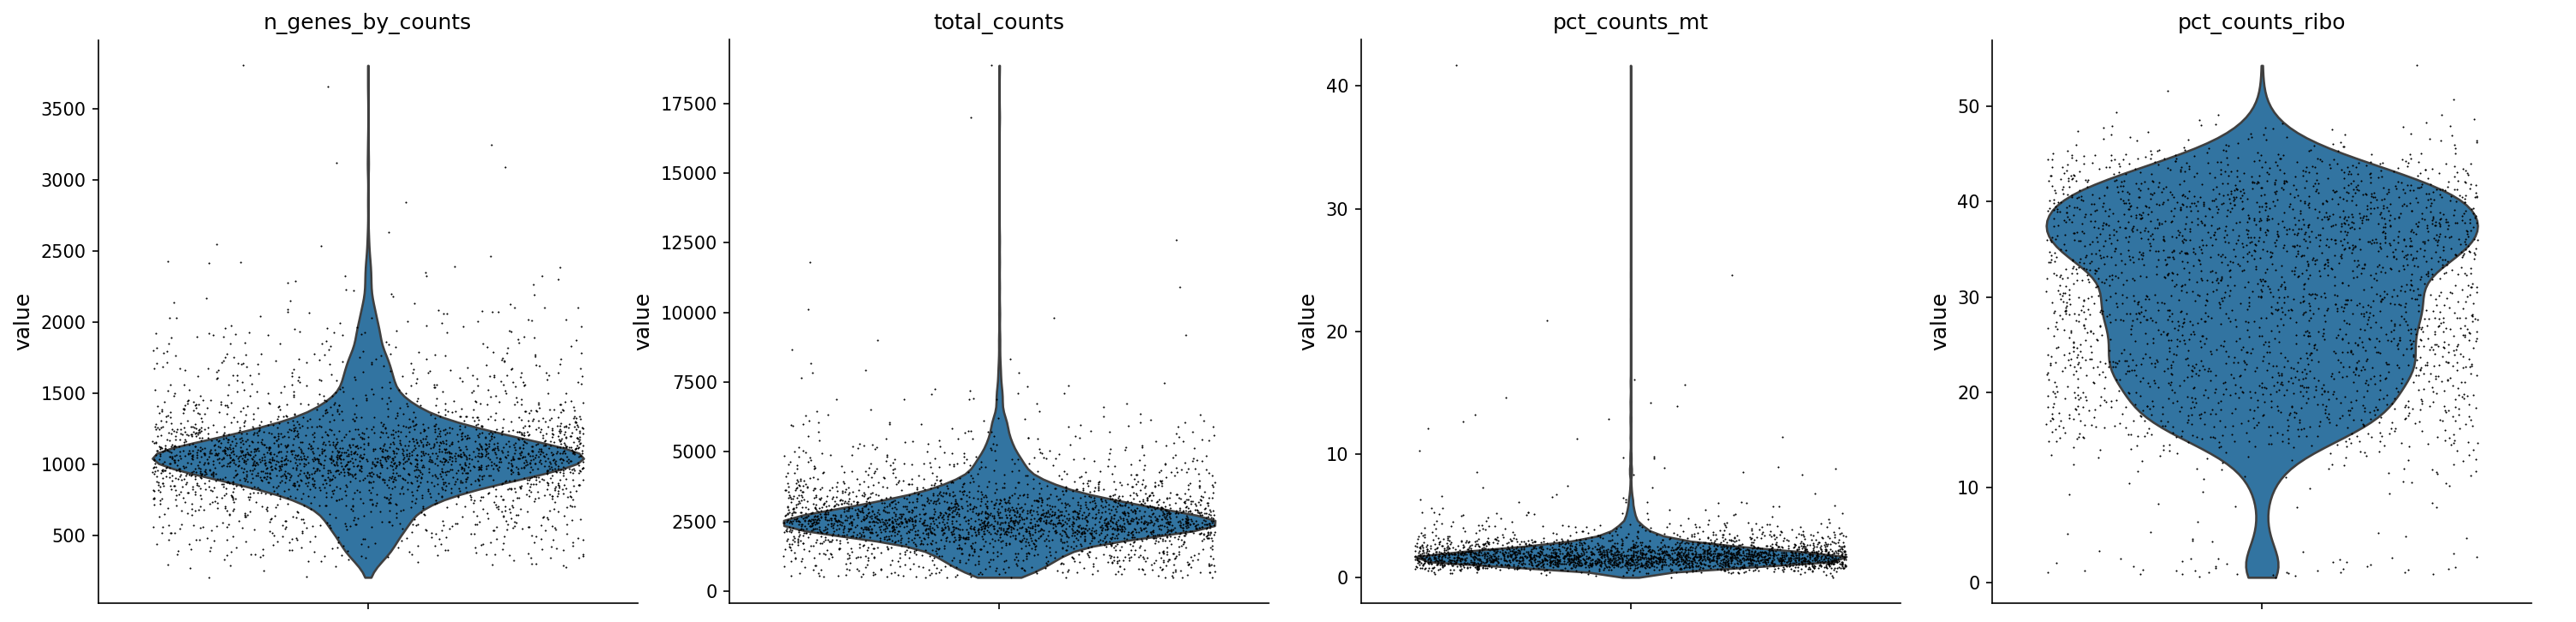

<Figure size 1500x900 with 0 Axes>

In [35]:
# TODO: (Optional) Create violin plots for total_counts, n_genes_by_counts, pct_counts_mt and save as results/qc/figures/violin_qc_metrics.png.
# TODO: Save the figure to disk.
sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo'],
    jitter=0.4,
    multi_panel=True,
)

fig = plt.gcf()

fig.savefig('../results/qc/violin_qc_metrics.png', dpi=150)

## 7) Descriptive Diagnostic Notes

**Goal:** Provide a short, fill-in template for observational notes from visualizations and tables. DO NOT change thresholds here — simply describe observations.

**Template (fill in):**
- Distribution notes (sketch):\n
- Outliers observed (cells with very low or very high counts):\n
- Suspected doublet tail (e.g., long high-count/high-gene tail):\n
- Mitochondrial distribution (heavy-tailed? percent high?):\n
- Any suspicious features (bimodality, unexpected gaps, annotation issues):\n

**Hard rule reminder:** No threshold changes or filtering in Week 2. Record all observations; filter decisions will be made later and must be documented.

## 8) Save ‘QC-metrics-added’ AnnData

**Goal:** Save an AnnData object that contains the original raw matrix plus the computed QC metrics so downstream steps can pick up metrics without re-running QC computation here.

**Save path:** `data/processed/pbmc_qc_metrics.h5ad`

**Actions (manual):** Write the AnnData to disk (ensure index integrity), and verify reloadability by re-opening and confirming the presence of the QC columns in `.obs`.

**Outputs:** `data/processed/pbmc_qc_metrics.h5ad`

**Pass/Fail check:** File created and reloadable; QC columns present in `.obs`.

In [47]:
# TODO: Save the AnnData object (with QC metrics in adata.obs) to data/processed/pbmc_qc_metrics.h5ad.
# TODO: After saving, attempt to reload the file and check that the QC columns exist in .obs.
# TODO: If reloading fails, record the error and do not overwrite the original raw file.
import scanpy as sc
adata.write('../data/processed/pbmc_qc_metrics.h5ad')
new_adata = sc.read_h5ad('../data/processed/pbmc_qc_metrics.h5ad')
new_adata.obs.columns

Index(['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts',
       'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo',
       'log1p_total_counts_ribo', 'pct_counts_ribo'],
      dtype='object')